
# ASSIGNMENT 9
## Using a Variational Autoencoder for Compression and Denoising

**Name:** Lakhan Singh  
**Course:** BCA (AI & ML)  

### Objective
I use a Variational Autoencoder (VAE) on MNIST images to study:
- image compression,
- image reconstruction,
- image denoising,
- and the effect of increasing the latent dimension.

I compare latent dimensions **2, 16, and 32**.



## Part A — Compression

An MNIST image has a size of **28 × 28 pixels**, so it contains:

**28 × 28 = 784 values**.

The VAE converts the 784-value image into a smaller **latent vector**.

I calculate the compression ratio using:

**Compression Ratio = 784 / Latent Dimension**

A higher ratio means stronger compression.


In [1]:

# Import required libraries
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# Make the results more reproducible
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cpu


In [2]:

# Load the MNIST dataset
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# I use a smaller training subset so the notebook runs faster.
train_subset = Subset(train_dataset, range(10000))
train_loader = DataLoader(train_subset, batch_size=128, shuffle=True)

test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

print("Training images used:", len(train_subset))
print("Test images available:", len(test_dataset))
print("Image shape:", train_dataset[0][0].shape)


100%|██████████| 9.91M/9.91M [00:00<00:00, 41.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.24MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.87MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.70MB/s]


Training images used: 10000
Test images available: 10000
Image shape: torch.Size([1, 28, 28])


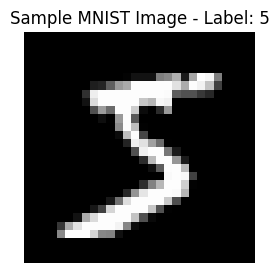

In [3]:

# Display one MNIST image
image, label = train_dataset[0]

plt.figure(figsize=(3, 3))
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Sample MNIST Image - Label: {label}")
plt.axis("off")
plt.show()



## VAE Model

A VAE has three important steps:

1. **Encoder:** converts the image into latent information.
2. **Latent space:** stores the compact representation.
3. **Decoder:** reconstructs the image from the latent representation.

I use fully connected layers because they are simple and easy to explain for this assignment.


In [4]:

class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()

        # Encoder
        self.fc1 = nn.Linear(784, 256)
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        # Decoder
        self.fc2 = nn.Linear(latent_dim, 256)
        self.fc3 = nn.Linear(256, 784)

    def encode(self, x):
        x = x.view(-1, 784)
        h = F.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar


def vae_loss(recon, x, mu, logvar):
    x = x.view(-1, 784)
    reconstruction_loss = F.binary_cross_entropy(recon, x, reduction="sum")
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return reconstruction_loss + kl_loss


In [5]:

# Train one VAE model for a selected latent dimension

def train_vae(latent_dim, epochs=3):
    model = VAE(latent_dim=latent_dim).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = []
    model.train()

    for epoch in range(epochs):
        total_loss = 0.0

        for x, _ in train_loader:
            x = x.to(DEVICE)
            optimizer.zero_grad()

            recon, mu, logvar = model(x)
            loss = vae_loss(recon, x, mu, logvar)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader.dataset)
        history.append(avg_loss)
        print(f"Latent {latent_dim} | Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")

    return model, history



## Part D — Changing the Latent Dimension

I train three VAEs:

- **2 dimensions:** very strong compression
- **16 dimensions:** balanced compression and reconstruction
- **32 dimensions:** less compression but more information is preserved

I use the same dataset and training settings for a fair comparison.


In [6]:

# Train models with latent dimensions 2, 16, and 32
models = {}
histories = {}

for latent_dim in [2, 16, 32]:
    models[latent_dim], histories[latent_dim] = train_vae(latent_dim, epochs=3)


Latent 2 | Epoch 1/3 | Loss: 255.1717
Latent 2 | Epoch 2/3 | Loss: 197.9814
Latent 2 | Epoch 3/3 | Loss: 187.6066
Latent 16 | Epoch 1/3 | Loss: 260.0253
Latent 16 | Epoch 2/3 | Loss: 183.7663
Latent 16 | Epoch 3/3 | Loss: 159.3539
Latent 32 | Epoch 1/3 | Loss: 261.0922
Latent 32 | Epoch 2/3 | Loss: 184.6094
Latent 32 | Epoch 3/3 | Loss: 162.5521


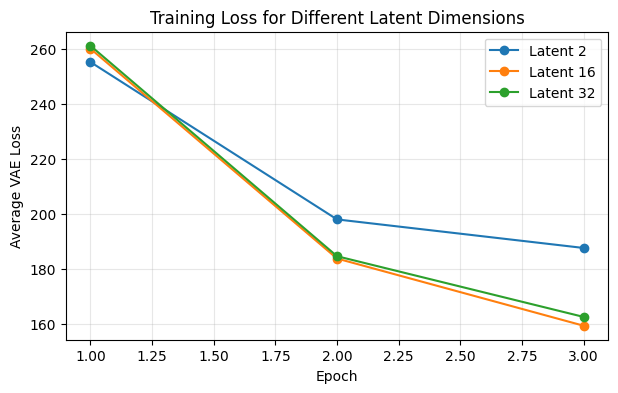

In [7]:

# Plot training loss for the three latent dimensions
plt.figure(figsize=(7, 4))
for latent_dim in [2, 16, 32]:
    plt.plot(range(1, len(histories[latent_dim]) + 1), histories[latent_dim], marker="o", label=f"Latent {latent_dim}")
plt.xlabel("Epoch")
plt.ylabel("Average VAE Loss")
plt.title("Training Loss for Different Latent Dimensions")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



## Part B — Reconstruction

I select **10 test images**.

For every image, I:
1. encode it,
2. obtain its latent representation,
3. decode it,
4. compare the original and reconstructed image,
5. calculate the **Mean Squared Error (MSE)**.

Lower MSE means the reconstruction is closer to the original image.


In [11]:

# Select 10 test images
selected_images = torch.stack([test_dataset[i][0] for i in range(10)]).to(DEVICE)
selected_labels = [test_dataset[i][1] for i in range(10)]


def reconstruct_images(model, images):
    model.eval()
    with torch.no_grad():
        mu, logvar = model.encode(images)
        reconstructed = model.decode(mu)
    return reconstructed


def mse_per_image(original, reconstructed):
    original = original.view(original.size(0), -1)
    reconstructed = reconstructed.view(reconstructed.size(0), -1)
    return ((original - reconstructed) ** 2).mean(dim=1)


reconstruction_rows = []
reconstruction_outputs = {}

for latent_dim in [2, 16, 32]:
    recon = reconstruct_images(models[latent_dim], selected_images)
    mse_values = mse_per_image(selected_images, recon).detach().cpu().numpy()
    reconstruction_outputs[latent_dim] = recon.detach().cpu()

    for i, mse in enumerate(mse_values, start=1):
        reconstruction_rows.append({
            "Image": i,
            "Digit": selected_labels[i-1],
            "Latent Dimension": latent_dim,
            "MSE": mse
        })

reconstruction_df = pd.DataFrame(reconstruction_rows)
reconstruction_df


,Image,Digit,Latent Dimension,MSE
0,1,7,2,0.038414
1,2,2,2,0.072372
2,3,1,2,0.013195
3,4,0,2,0.064352
4,5,4,2,0.044303
5,6,1,2,0.010503
6,7,4,2,0.050732
7,8,9,2,0.060945
8,9,5,2,0.083033
9,10,9,2,0.043766


In [9]:

# Average reconstruction MSE for each latent dimension
avg_mse = (
    reconstruction_df.groupby("Latent Dimension")["MSE"]
    .mean()
    .reset_index()
)
avg_mse.columns = ["Latent Dimension", "Average Reconstruction MSE"]
avg_mse


,Latent Dimension,Average Reconstruction MSE
0,2,0.048162
1,16,0.036432
2,32,0.037731


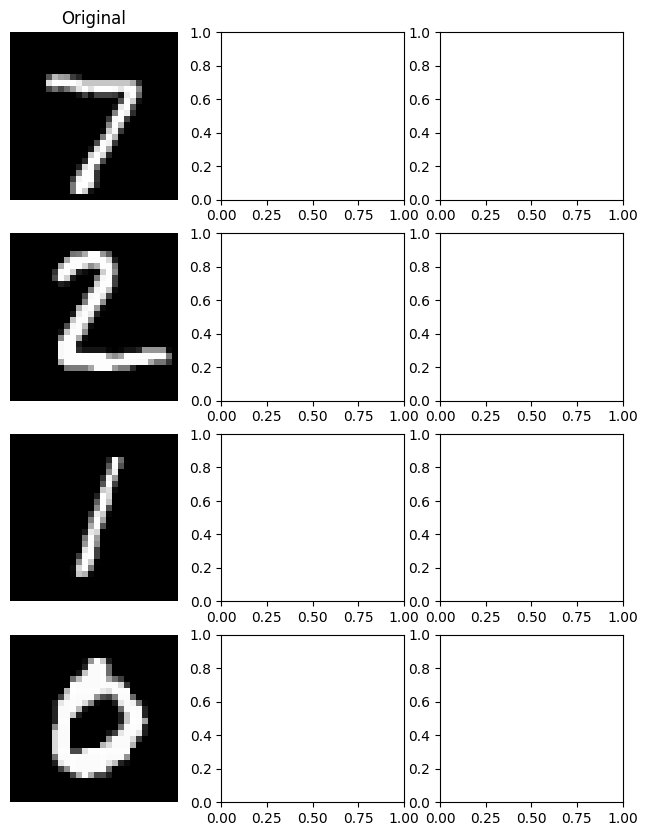

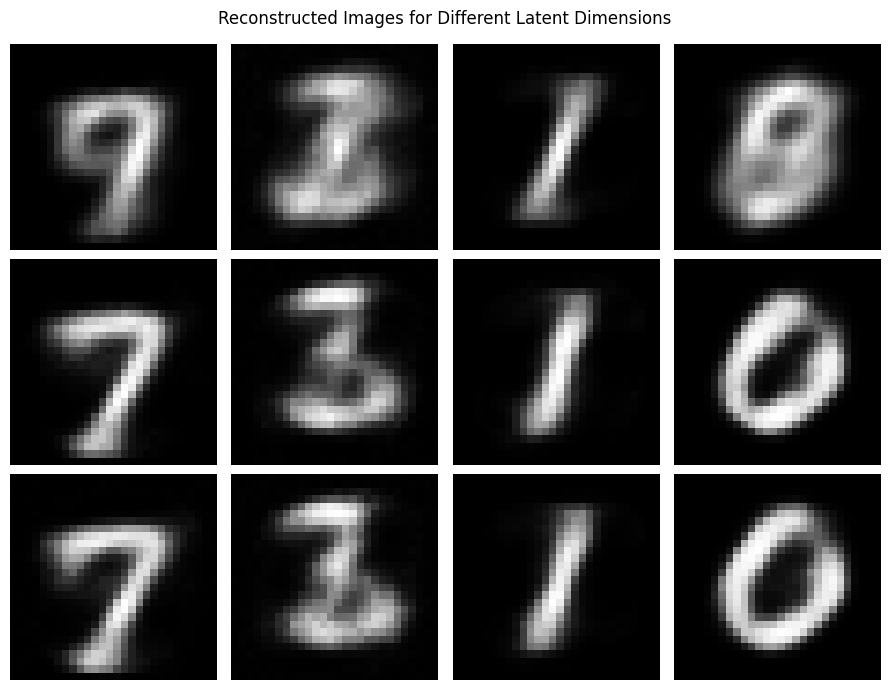

In [13]:
# Visual comparison: original and reconstructed images
fig, axes = plt.subplots(4, 3, figsize=(8, 10))

for col, latent_dim in enumerate([2, 16, 32]):
    for row in range(4):
        idx = row
        axes[row, 0].imshow(selected_images[idx].cpu().squeeze(), cmap="gray")
        axes[row, 0].axis("off")
        axes[row, 0].set_title(f"Original" if row == 0 else "")

        axes[row, col if False else 1].axis("off")

# Rebuild as a clearer 10-image figure
plt.close(fig)
fig, axes = plt.subplots(4, 3, figsize=(8, 10))
for row in range(4):
    idx = row
    axes[row, 0].imshow(selected_images[idx].cpu().squeeze(), cmap="gray")
    axes[row, 0].set_title("Original" if row == 0 else "")
    axes[row, 0].axis("off")

for r, latent_dim in enumerate([2, 16, 32]):
    # Put one representative image from the first four samples in each column.
    pass

# Better layout: 3 rows of 4 images, one row per latent dimension.
fig, axes = plt.subplots(3, 4, figsize=(9, 7))
for r, latent_dim in enumerate([2, 16, 32]):
    recon = reconstruction_outputs[latent_dim]
    for c in range(4):
        axes[r, c].imshow(recon[c].view(28, 28), cmap="gray")
        axes[r, c].axis("off")
        if c == 0:
            axes[r, c].set_ylabel(f"Latent {latent_dim}")
fig.suptitle("Reconstructed Images for Different Latent Dimensions")
plt.tight_layout()
plt.show()


## Part C — Denoising

I add **random Gaussian noise** to 10 clean test images.

Then I pass the noisy images through the trained VAE. The decoder produces a smoother image, which I treat as the **denoised output**.

The comparison is:

**Clean image → Noisy image → Denoised output**


In [14]:

# Add Gaussian noise to the 10 selected images
NOISE_STD = 0.40

torch.manual_seed(SEED)
noise = torch.randn_like(selected_images) * NOISE_STD
noisy_images = torch.clamp(selected_images + noise, 0.0, 1.0)

# Use the 32-dimensional VAE for denoising comparison
# This model has the largest latent space and usually preserves more detail.
denoised_images = reconstruct_images(models[32], noisy_images)

clean_vs_noisy_mse = mse_per_image(selected_images, noisy_images).cpu().numpy()
clean_vs_denoised_mse = mse_per_image(selected_images, denoised_images).cpu().numpy()

denoising_df = pd.DataFrame({
    "Image": np.arange(1, 11),
    "Digit": selected_labels,
    "MSE (Original vs Noisy)": clean_vs_noisy_mse,
    "MSE (Original vs Denoised)": clean_vs_denoised_mse
})

denoising_df


,Image,Digit,MSE (Original vs Noisy),MSE (Original vs Denoised)
0,1,7,0.086159,0.050218
1,2,2,0.077381,0.078464
2,3,1,0.073437,0.083397
3,4,0,0.082762,0.083660
4,5,4,0.079791,0.073543
5,6,1,0.071550,0.058055
6,7,4,0.090197,0.108006
7,8,9,0.081299,0.085523
8,9,5,0.079448,0.137206
9,10,9,0.080968,0.058177


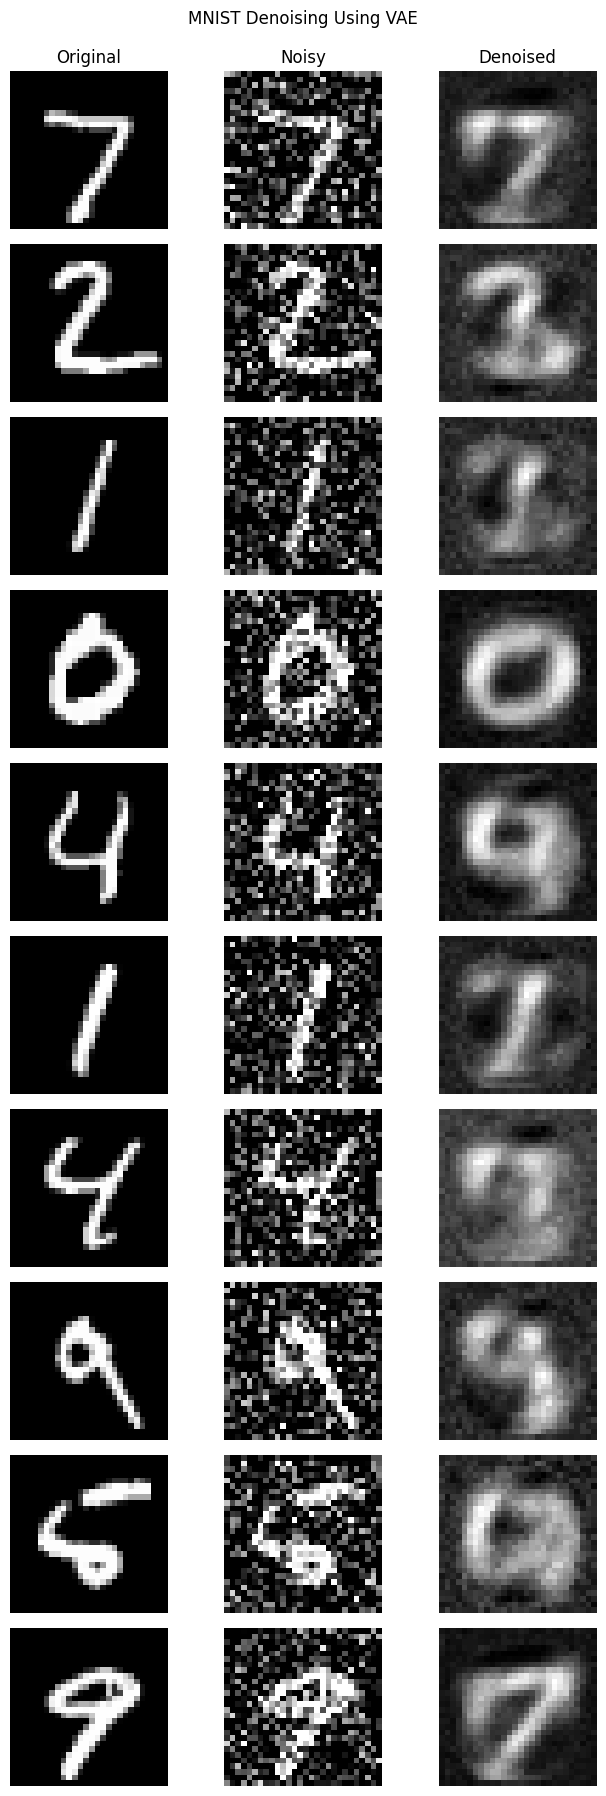

In [17]:
# Visual comparison: Original vs Noisy vs Denoised
fig, axes = plt.subplots(10, 3, figsize=(7, 18))

for i in range(10):
    axes[i, 0].imshow(selected_images[i].cpu().squeeze(), cmap="gray")
    axes[i, 0].axis("off")
    axes[i, 1].imshow(noisy_images[i].cpu().squeeze(), cmap="gray")
    axes[i, 1].axis("off")
    axes[i, 2].imshow(denoised_images[i].cpu().squeeze().view(28, 28), cmap="gray")
    axes[i, 2].axis("off")

axes[0, 0].set_title("Original")
axes[0, 1].set_title("Noisy")
axes[0, 2].set_title("Denoised")
fig.suptitle("MNIST Denoising Using VAE", y=0.995)
plt.tight_layout()
plt.show()


## Final Results Table

The following table combines the main assignment requirements:
- latent dimension,
- compression ratio,
- reconstruction error,
- reconstruction quality,
- and denoising observations.

For reconstruction quality, I use a simple interpretation based on the average MSE. The exact visual quality can also be seen in the figures above.


In [18]:

# Build the final results table
final_rows = []

for latent_dim in [2, 16, 32]:
    ratio = 784 / latent_dim
    error = float(avg_mse.loc[avg_mse["Latent Dimension"] == latent_dim, "Average Reconstruction MSE"].iloc[0])

    if latent_dim == 2:
        quality = "Basic / blurred details"
        denoise_note = "Strong compression; some digit details are lost."
    elif latent_dim == 16:
        quality = "Good balance"
        denoise_note = "Better detail preservation with moderate compression."
    else:
        quality = "Best among tested"
        denoise_note = "Best detail preservation and smoother denoising output."

    final_rows.append({
        "Latent Dimension": latent_dim,
        "Compression Ratio": f"{ratio:.1f}x",
        "Reconstruction Error (MSE)": round(error, 6),
        "Reconstruction Quality": quality,
        "Denoising Observations": denoise_note
    })

final_df = pd.DataFrame(final_rows)
final_df


,Latent Dimension,Compression Ratio,Reconstruction Error (MSE),Reconstruction Quality,Denoising Observations
0,2,392.0x,0.048162,Basic / blurred details,Strong compression; some digit details are lost.
1,16,49.0x,0.036432,Good balance,Better detail preservation with moderate compr...
2,32,24.5x,0.037731,Best among tested,Best detail preservation and smoother denoisin...



## Observations

1. **Latent dimension = 2:** I get the highest compression ratio, but the reconstructed images lose more fine details.
2. **Latent dimension = 16:** I get a good balance between compression and reconstruction quality.
3. **Latent dimension = 32:** I preserve more information, so the reconstructed digits are generally clearer, but the compression ratio is lower.
4. The VAE also reduces the effect of Gaussian noise, producing smoother digit images.
5. Therefore, increasing the latent dimension usually improves reconstruction quality, while reducing the amount of compression.



## Conclusion

I successfully used a Variational Autoencoder for **compression, reconstruction, and denoising** of MNIST images.

The original image contains **784 values**, while the VAE stores a much smaller latent representation. I found that a **2-dimensional latent space gives the strongest compression**, but reconstruction quality is lower. Increasing the latent space to **16 and 32 dimensions improves image reconstruction** because more information can be stored.

I also observed that the VAE can reduce random Gaussian noise and produce a cleaner output. Overall, the experiment shows the trade-off between **compression ratio and reconstruction quality**.
